# Quantized CNN Training for Posture Classification (HGQ2-based QAT)

## Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Keras 3
import keras

# TensorFlow
import tensorflow as tf

# Package imports
from bedposip.data import load_dataset
from bedposip.model import (
    create_quantized_model,
    get_callbacks,
    train_model,
)
from bedposip.utils import (
    check_layer_trainable_params,
    plot_training_history,
    class_report_metric,
    save_model,
    inspect_quantization_bits, 
    plot_quantization_bits
)

# HGQ2 quantization-aware training
from hgq.config import QuantizerConfigScope, LayerConfigScope
from hgq.utils import trace_minmax
from hgq.constraints import MinMax, Max

# Configure matplotlib for PDF export with serif font
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern Serif",
})

# Ensure figures directory exists
os.makedirs('figures', exist_ok=True)

I0000 00:00:1785126184.391209   44664 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Set random seed for reproducibility
np.random.seed(42)
keras.utils.set_random_seed(42)

# Constant number of postures
NUM_CLASSES = 3

# Constant for training quantizers bit-width optimizations
REGULARIZER = 1e-5

# Check GPU
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data

### Loading

In [3]:
# Load datasets using package function
X_train, y_train, X_val, y_val, X_test, y_test = load_dataset()


Dataset shapes:
  Train: (119999, 8, 8, 1), labels: (119999,)
  Val:   (60000, 8, 8, 1), labels: (60000,)
  Test:  (120001, 8, 8, 1), labels: (120001,)


### Encoding

In [4]:
class_names = {"lateral_L": 0, "lateral_R": 1, "supine": 2}

## Configuration

In [5]:
# Define callbacks using package function
# BetaPID dynamically adjusts beta to steer the model toward a target EBOPs budget.
callbacks = get_callbacks(
    model_name='qat',
    patience=30,
    track_ebops=True,
    target_ebops=800_000,
    init_beta=1e-7,
)

Callbacks configured:
  - EarlyStopping
  - ReduceLROnPlateau
  - FreeEBOPs
  - BetaPID


## Quantized Model

HGQ2 Quantization Configuration

- **`kbi` quantizer** for weights: symmetric saturation overflow
- **`kif` quantizer** for activations (datalane): wrap-around overflow
- **No softmax in the model**: The output layer produces raw logits

> "QSoftmax is bit-accurate, but it can give exactly zero now: xentropy will diverge and thus USE WITH CAUTION. For classification, it is recommended to NOT to use softmax in the model, but to use it in the loss function"

This approach follows the best practices demonstrated in [1] `small_jet_tagger.ipynb` and [2] `larger_jet_tagger.ipynb`.

In [6]:
with (
    QuantizerConfigScope(place='all', default_q_type='kbi', overflow_mode='SAT_SYM'),
    QuantizerConfigScope(
        place='weight',
        bc=Max(6),
        ic=Max(4),
        i0=2, b0=6,
        default_q_type='kbi', overflow_mode='SAT_SYM'
    ),
    QuantizerConfigScope(
        place='datalane',
        fc=Max(3),
        ic=Max(6),
        i0=3, f0=3,
        heterogeneous_axis=(),
        default_q_type='kif', overflow_mode='WRAP'
    ),
    LayerConfigScope(enable_ebops=True),  # beta managed by BetaPID callback
):
    model_qat = create_quantized_model(num_classes=NUM_CLASSES)
    model_qat.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy'],
    )

model_qat.summary()

I0000 00:00:1785126186.647923   44664 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5440 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:10:00.0, compute capability: 8.6


Model: "posture_classifier_qat"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pressure_map (InputLayer)       │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_1 (QConv2D)               │ (None, 6, 6, 24)       │           870 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qbn_conv_1                      │ (None, 6, 6, 24)       │           246 │
│ (QBatchNormalization)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_act_1 (Activation)        │ (None, 6, 6, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_2 (QConv2D)               │ (None, 4, 4, 20)       │        17,286 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qbn_conv_2                      │ (None, 4, 4, 20)       │           206 │
│ (QBatchNormalization)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_act_2 (Activation)        │ (None, 4, 4, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_3 (QConv2D)               │ (None, 2, 2, 36)       │        25,926 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qbn_conv_3                      │ (None, 2, 2, 36)       │           366 │
│ (QBatchNormalization)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_act_3 (Activation)        │ (None, 2, 2, 36)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_max_pooling2d (QMaxPooling2D) │ (None, 1, 1, 36)       │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qdense_1 (QDense)               │ (None, 26)             │         3,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qbn_dense_1                     │ (None, 26)             │           266 │
│ (QBatchNormalization)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 26)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qdense_2 (QDense)               │ (None, 10)             │         1,046 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qbn_dense_2                     │ (None, 10)             │           106 │
│ (QBatchNormalization)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (QDense)                 │ (None, 3)              │           138 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,212 (159.55 KB)

 Trainable params: 37,443 (146.26 KB)

 Non-trainable params: 12,769 (13.29 KB)

In [7]:
check_layer_trainable_params(model_qat)

qconv_1: 216
qbn_conv_1: 24
qconv_2: 4320
Layer qconv_2 is too large (4320), are you sure you want to train?
qbn_conv_2: 20
qconv_3: 6480
Layer qconv_3 is too large (6480), are you sure you want to train?
qbn_conv_3: 36
qdense_1: 936
qbn_dense_1: 26
qdense_2: 260
qbn_dense_2: 10
output: 30


### Training

Epoch 1/500


I0000 00:00:1785126194.471819   44728 service.cc:153] XLA service 0x7fe25805d5a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785126194.471833   44728 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070, Compute Capability 8.6 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1785126194.737090   44728 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785126195.983853   44728 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1785126196.072456   44728 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22431__.124


11/59 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3991 - loss: 1.6428

I0000 00:00:1785126210.837406   44728 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


50/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5167 - loss: 1.4676 

I0000 00:00:1785126212.481628   44727 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22431__.124


59/59 ━━━━━━━━━━━━━━━━━━━━ 44s 366ms/step - accuracy: 0.6216 - loss: 1.3074 - val_accuracy: 0.4414 - val_loss: 1.5391 - learning_rate: 0.0010 - ebops: 4633220.0000 - beta: 1.0000e-07
Epoch 2/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7663 - loss: 1.0509 - val_accuracy: 0.5204 - val_loss: 1.4094 - learning_rate: 0.0010 - ebops: 4635464.0000 - beta: 1.0000e-07
Epoch 3/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8098 - loss: 0.9500 - val_accuracy: 0.5715 - val_loss: 1.0757 - learning_rate: 0.0010 - ebops: 4634840.0000 - beta: 1.0000e-07
Epoch 4/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8307 - loss: 0.8989 - val_accuracy: 0.5734 - val_loss: 1.1836 - learning_rate: 0.0010 - ebops: 4635704.0000 - beta: 1.0000e-07
Epoch 5/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8422 - loss: 0.8689 - val_accuracy: 0.6703 - val_loss: 0.8596 - learning_rate: 0.0010 - ebops: 4635704.0000 - beta: 1.0000e-07
Epoch 6/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/ste

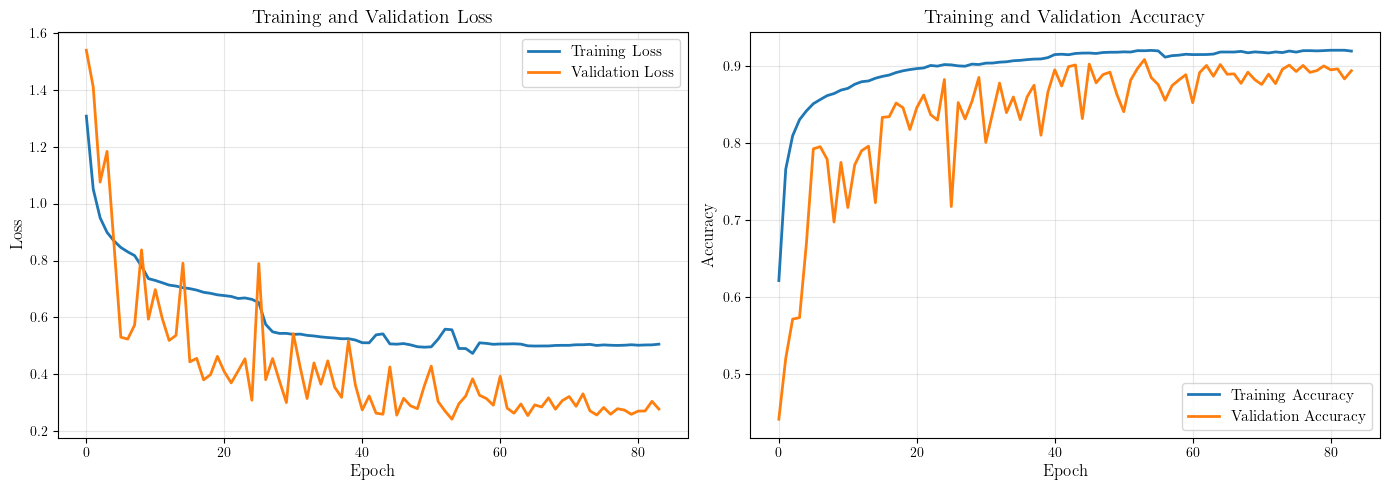

In [8]:
history_qat = train_model(model_qat, X_train,y_train, X_val, y_val, callbacks, batch_size=2048, epochs=500) # Batch according to HGQ article
plot_training_history(history_qat, model_name='posture_classifier_qat', save=True)

## Model Evaluation


Accuracy Report for `posture_classifier_qat`:
  Loss: 0.2481
  Accuracy: 90.62%

Classification Report for `posture_classifier_qat`:
              precision    recall  f1-score   support

   lateral_L     0.9191    0.8897    0.9041     40000
   lateral_R     0.8894    0.9238    0.9063     40000
      supine     0.9113    0.9052    0.9082     40001

    accuracy                         0.9062    120001
   macro avg     0.9066    0.9062    0.9062    120001
weighted avg     0.9066    0.9062    0.9062    120001

Saved: figures/cm_posture_classifier_qat.pdf


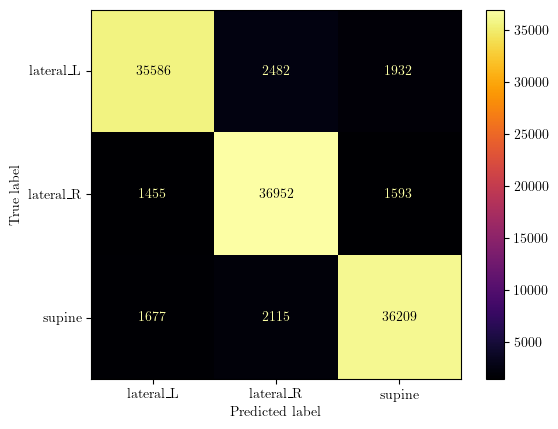

(array([[ 2.2265625,  0.71875  , -0.9921875],
        [ 4.9140625, -3.65625  ,  1.34375  ],
        [-3.328125 , -1.8671875,  2.9765625],
        ...,
        [ 4.1484375, -0.4921875,  2.0234375],
        [-2.921875 , -2.0859375,  3.421875 ],
        [-3.5390625, -3.9921875,  5.1484375]],
       shape=(120001, 3), dtype=float32),
 0.9062174481879318,
 0.24813894516486584)

In [9]:
class_report_metric(model_qat, X_test, y_test, class_names, save=True)

In [10]:
# From larger_jet_tagger

# When using `WRAP` overflow mode for activations (datalane), HGQ2 needs to know the min/max values of each layer's activations to determine the required integer bits. 
trace_minmax(model_qat, X_train, batch_size=2048, reset=True)
ebops = trace_minmax(model_qat, X_val, batch_size=2048, reset=False)

lut_pred = np.exp(0.985 * np.log(ebops))
dsp_pred = (ebops - lut_pred) / 55

print("Resource Estimation Report")
print("="*40)
print(f"\nEBOPs: {ebops} \nLUTs: {lut_pred:.0f} \nDSPs: {dsp_pred:.0f}")

Resource Estimation Report

EBOPs: 3436693 
LUTs: 2742197 
DSPs: 12627


In [11]:
## Determine accuracy of Keras model, for comparison
keras_score = model_qat.evaluate(X_test, y_test, verbose=0)

print("="*80)    
print("Keras  model evaluation \t Loss: {:.2f} \t Accuracy: {:.2f}%".format(keras_score[0], keras_score[1]*100))
print("="*80)

Keras  model evaluation 	 Loss: 0.47 	 Accuracy: 82.61%



Quantization Bit-width Report:
pressure_map: InputLayer (no quantizers)

qconv_1 (QConv2D):
  iq: bits=6.00, fbits=6.00, type=kif
  kq: bits=5.91, fbits=6.91, type=kbi

qbn_conv_1 (QBatchNormalization):
  iq: bits=7.00, fbits=8.00, type=kif
  kq: bits=6.00, fbits=7.00, type=kbi
  bq: bits=4.38, fbits=5.38, type=kbi
qconv_act_1: Activation (no quantizers)

qconv_2 (QConv2D):
  iq: bits=6.00, fbits=6.00, type=kif
  kq: bits=5.46, fbits=6.46, type=kbi

qbn_conv_2 (QBatchNormalization):
  iq: bits=8.00, fbits=9.00, type=kif
  kq: bits=6.00, fbits=7.00, type=kbi
  bq: bits=4.95, fbits=5.95, type=kbi
qconv_act_2: Activation (no quantizers)

qconv_3 (QConv2D):
  iq: bits=5.00, fbits=5.00, type=kif
  kq: bits=5.99, fbits=6.99, type=kbi

qbn_conv_3 (QBatchNormalization):
  iq: bits=8.00, fbits=9.00, type=kif
  kq: bits=6.00, fbits=7.00, type=kbi
  bq: bits=4.25, fbits=5.25, type=kbi
qconv_act_3: Activation (no quantizers)
q_max_pooling2d: QMaxPooling2D (no quantizers)
flatten: Flatten (no quan

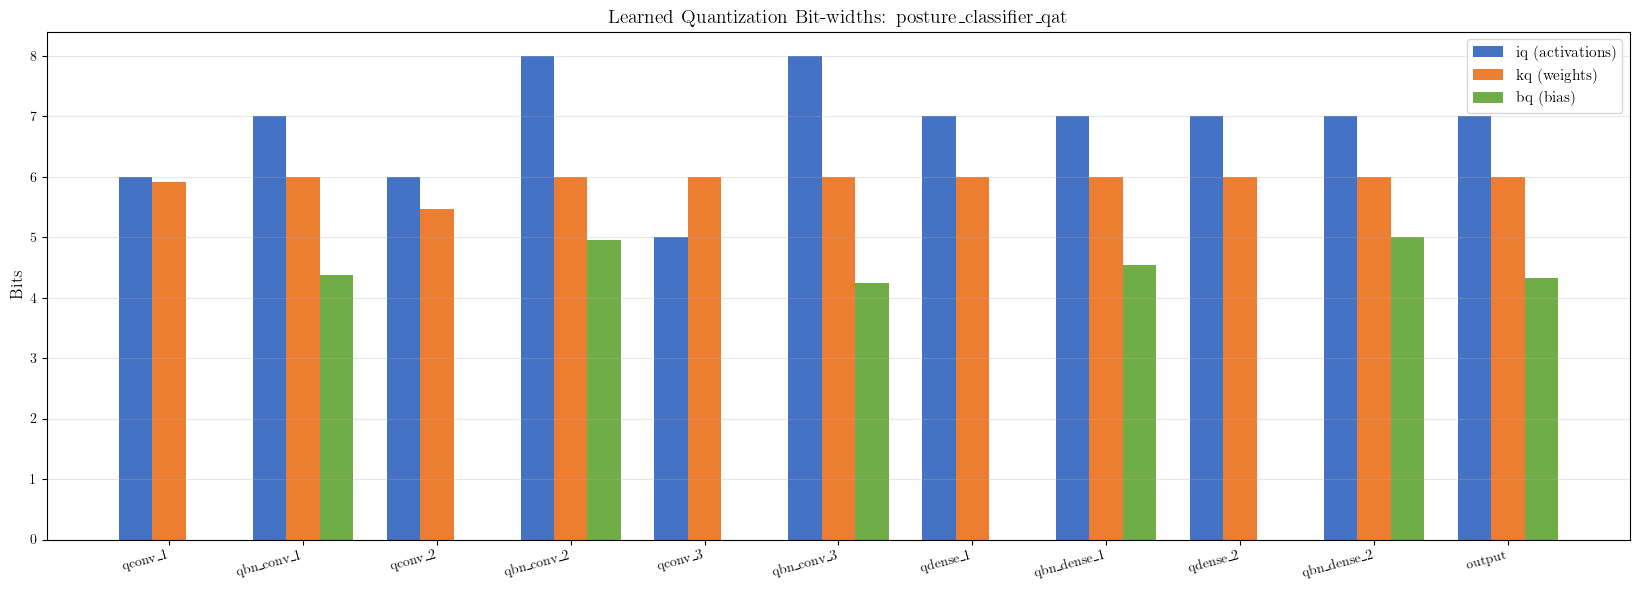

In [12]:
# Inspect learned quantization bit-widths
bits_info = inspect_quantization_bits(model_qat, report=True)

plot_quantization_bits(model_qat, bits_info=bits_info, save=False)

## Model Saving

In [13]:
# Save model
save_model(model_qat, output_dir='output')


Model saved to: output/posture_classifier_qat.keras

Verification:
  Loaded successfully: True
  Model name: posture_classifier_qat
  Total parameters: 50,212
